# YOLOv8 Raw Dataset Training and Evaluation
This notebook trains and evaluates a YOLOv8 detector using **raw data** and **online augmentation only**.

In [1]:
%%capture
!pip install ultralytics

In [9]:
!find /content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main -name "*.cache" -delete

In [2]:
%matplotlib inline

import os
import random
import csv
from pathlib import Path
import cv2

import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pandas as pd
from PIL import Image
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
try:
  from google.colab import drive
  drive.mount("/content/drive")
  ROOT = "drive/MyDrive/CS231/CS231_VehicleDetection"
  DEVICE = 'cuda'
except:
  ROOT = "../"
  DEVICE = 'cpu'

Mounted at /content/drive


In [4]:
# Configuration
CLASS_NAMES = ['Bus', 'Car', 'Motorcycle', 'Pickup', 'Truck']
DATA_ROOT = Path(f"{ROOT}/data/main")
DATASET_YAML = f"{DATA_ROOT}/data.yaml"
PRETRAINED_WEIGHTS = 'yolov8n.pt'

OUTPUT_DIR = Path(f"{ROOT}/outputs/runs/detect").resolve()
VAL_OUTPUT_DIR = Path(f"{ROOT}//outputs/runs/val").resolve()

EPOCHS = 100
IMG_SIZE = 832
BATCH = 8
random.seed(42)

In [5]:
# Validate dataset structure
required_dirs = [
    DATA_ROOT / 'train' / 'images',
    DATA_ROOT / 'train' / 'labels',
    DATA_ROOT / 'valid' / 'images',
    DATA_ROOT / 'valid' / 'labels',
    DATA_ROOT / 'test' / 'images',
    DATA_ROOT / 'test' / 'labels',
]
missing = [str(p) for p in required_dirs if not p.exists()]
if missing:
    raise FileNotFoundError('Missing dataset paths:\n' + '\n'.join(missing))
print('Dataset structure looks good.')

Dataset structure looks good.


## Load pretrained model
Pretrained weights (`yolov8n.pt`) are used to start from strong generic visual features, which usually improves convergence speed and baseline performance compared with training from scratch.

In [6]:
model = YOLO(PRETRAINED_WEIGHTS)
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

In [7]:
# Train with YOLOv8 built-in online augmentation only
train_results = model.train(
    data=str(DATASET_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    project=str(OUTPUT_DIR),
    name='yolov8_raw_no_aug',
    exist_ok=True,
    # optimizer
    optimizer="SGD",
    lr0=0.01,
    lrf=0.01,
    momentum=0.937,
    weight_decay=5e-4,
    # scheduler
    cos_lr=True,
    # caching
    cache=True,
    patience=20
)

run_dir = Path(train_results.save_dir)
best_model_path = run_dir / 'weights' / 'best.pt'
results_csv_path = run_dir / 'results.csv'
print(f'Run dir: {run_dir}')
print(f'Best model: {best_model_path}')

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=drive/MyDrive/CS231/CS231_VehicleDetection/data/main/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=832, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_raw_no_aug, nbs=64, nms=False, opset=None, optimize=False, optimizer

In [10]:
# Evaluate on validation set
best_model = YOLO(str(best_model_path)) if best_model_path.exists() else model
metrics = best_model.val(
    data=str(DATASET_YAML),
    split="val",

    project=str(VAL_OUTPUT_DIR),
    name="yolov8_validation",

    exist_ok=True
)

map50 = float(metrics.box.map50)
map5095 = float(metrics.box.map)
precision = float(metrics.box.mp)
recall = float(metrics.box.mr)

print("Validation metrics:")

print(f"mAP50: {map50:.4f}")
print(f"mAP50-95: {map5095:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.9±0.5 ms, read: 40.7±20.0 MB/s, size: 81.5 KB)
val: Scanning /content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/valid/labels... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 3.7it/s 27.0s
val: New cache created: /content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.4it/s 5.0s
                   all        100       1107      0.938      0.906      0.949      0.781
                   bus         35         37          1      0.888       0.95      0.896
                   car         92        366      0.948      0.948      0.977      0.802
             motorbike         90        611      0.893      0.818      0.895      0.565


In [11]:
# CELL: EVALUATE ON TEST SET

# Load best model
best_model=YOLO(str(best_model_path)) if best_model_path.exists() else model

# Evaluate on test set
metrics=best_model.val(
    data=str(DATASET_YAML),
    split="test",

    project=str(VAL_OUTPUT_DIR),
    name="yolov8_test_evaluation",

    exist_ok=True
)

# Detection metrics
map50=float(metrics.box.map50)
map5095=float(metrics.box.map)

precision=float(metrics.box.mp)
recall=float(metrics.box.mr)

# Inference time
inference_time=metrics.speed['inference']

# FPS
fps=1000/inference_time if inference_time>0 else 0

print('TEST METRICS')

print(f'mAP50: {map50:.4f}')
print(f'mAP50-95: {map5095:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')

print(f'Average Inference Time: {inference_time:.2f} ms/image')
print(f'FPS: {fps:.2f}')

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 1.1±1.1 ms, read: 10.1±22.0 MB/s, size: 75.4 KB)
val: Scanning /content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/test/labels... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 3.7it/s 26.7s
val: New cache created: /content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.3it/s 5.2s
                   all        100       1133       0.93      0.901      0.946      0.767
                   bus         40         43      0.948       0.93       0.96      0.868
                   car         92        369      0.931      0.948      0.976      0.831
             motorbike         95        628      0.895      0.819      0.901       0.56
  

In [12]:
# Test inference and save predictions
pred_results = best_model.predict(
    source=str(DATA_ROOT / 'test' / 'images'),
    save=True,
    project=OUTPUT_DIR,
    name=f'{run_dir.name}_test_preds',
    exist_ok=True,
    conf=0.25,
)
pred_save_dir = Path(pred_results[0].save_dir) if pred_results else Path('runs/detect')
print(f'Test predictions saved to: {pred_save_dir}')


image 1/100 /content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/test/images/image_1_1006_jpg.rf.65087e32ceb6d70e6f7dc81077c63093.jpg: 832x832 5 cars, 10 motorbikes, 15.2ms
image 2/100 /content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/test/images/image_1_127_jpg.rf.e378c858eb0d4dc5f609bdf70f4dff9d.jpg: 832x832 4 cars, 20 motorbikes, 11.2ms
image 3/100 /content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/test/images/image_1_1281_jpg.rf.90f0eb6c0e54904035864e8eca93f267.jpg: 832x832 1 bus, 10.9ms
image 4/100 /content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/test/images/image_1_1449_jpg.rf.cef2ca56f852e86e8a0487c11c01bcc7.jpg: 832x832 1 bus, 2 cars, 13 motorbikes, 1 truck, 10.9ms
image 5/100 /content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/test/images/image_1_1751_jpg.rf.d33c55fa3cf0de702122d62225a1c7f4.jpg: 832x832 2 motorbikes, 1 truck, 10.8ms
image 6/100 /content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/test/images/imag

In [13]:
best_model_path = Path(f"{OUTPUT_DIR}/yolov8_raw_no_aug/weights/best.pt")
best_model = YOLO(best_model_path)
results_csv_path = Path(f"{OUTPUT_DIR}/yolov8_raw_no_aug/results.csv")

In [14]:
# Visualize random predictions
test_images_dir = DATA_ROOT / 'test' / 'images'
image_paths = [p for p in test_images_dir.iterdir() if p.suffix.lower() == '.jpg']
n = min(4, len(image_paths))

if n == 0:
    print('No test images found for visualization.')
else:
    selected = random.sample(image_paths, n)
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 6 * rows))
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1:
        axes = list(axes)
    else:
        axes = axes.flatten()

    for ax, img_path in zip(axes, selected):
        result = best_model.predict(source=str(img_path), conf=0.25, verbose=False)[0]
        image = Image.open(img_path).convert('RGB')
        ax.imshow(image)
        ax.set_title(img_path.name)
        ax.axis('off')

        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            w, h = x2 - x1, y2 - y1
            cls_id = int(box.cls[0].item()) if box.cls is not None else -1
            conf = float(box.conf[0].item()) if box.conf is not None else 0.0
            cls_name = best_model.names.get(cls_id, str(cls_id))

            rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, max(y1 - 6, 0), f'{cls_name} {conf:.2f}', color='white', fontsize=9,
                    bbox=dict(facecolor='green', alpha=0.7, pad=1))

    for ax in axes[n:]:
        ax.axis('off')

    fig.suptitle('Random Test Predictions', fontsize=16)
    plt.tight_layout()
    plt.show()
    print(f'✓ Displayed {n} random test predictions')

Output hidden; open in https://colab.research.google.com to view.

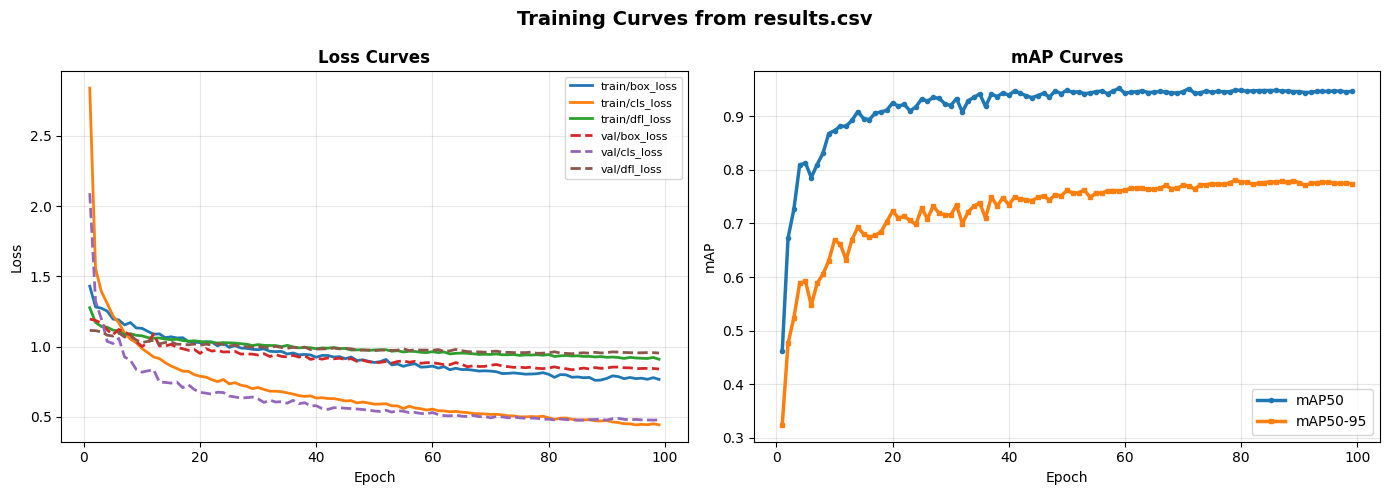

✓ Training curves plotted for 99 epochs


In [15]:
# Plot training curves from results.csv
if not results_csv_path.exists():
    print(f'results.csv not found: {results_csv_path}')
else:
    with open(results_csv_path, 'r', encoding='utf-8') as f:
        rows = list(csv.DictReader(f))

    epochs = [int(float(r.get('epoch', i))) for i, r in enumerate(rows)]

    def series(key):
        vals = []
        for r in rows:
            try:
                vals.append(float(r.get(key, 'nan')))
            except ValueError:
                vals.append(float('nan'))
        return vals

    train_box = series('train/box_loss')
    train_cls = series('train/cls_loss')
    train_dfl = series('train/dfl_loss')
    val_box = series('val/box_loss')
    val_cls = series('val/cls_loss')
    val_dfl = series('val/dfl_loss')
    map50_curve = series('metrics/mAP50(B)')
    map5095_curve = series('metrics/mAP50-95(B)')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, train_box, label='train/box_loss', linewidth=2)
    axes[0].plot(epochs, train_cls, label='train/cls_loss', linewidth=2)
    axes[0].plot(epochs, train_dfl, label='train/dfl_loss', linewidth=2)
    axes[0].plot(epochs, val_box, '--', label='val/box_loss', linewidth=2)
    axes[0].plot(epochs, val_cls, '--', label='val/cls_loss', linewidth=2)
    axes[0].plot(epochs, val_dfl, '--', label='val/dfl_loss', linewidth=2)
    axes[0].set_title('Loss Curves', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, map50_curve, label='mAP50', linewidth=2.5, marker='o', markersize=3)
    axes[1].plot(epochs, map5095_curve, label='mAP50-95', linewidth=2.5, marker='s', markersize=3)
    axes[1].set_title('mAP Curves', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('mAP')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    fig.suptitle('Training Curves from results.csv', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'✓ Training curves plotted for {len(epochs)} epochs')

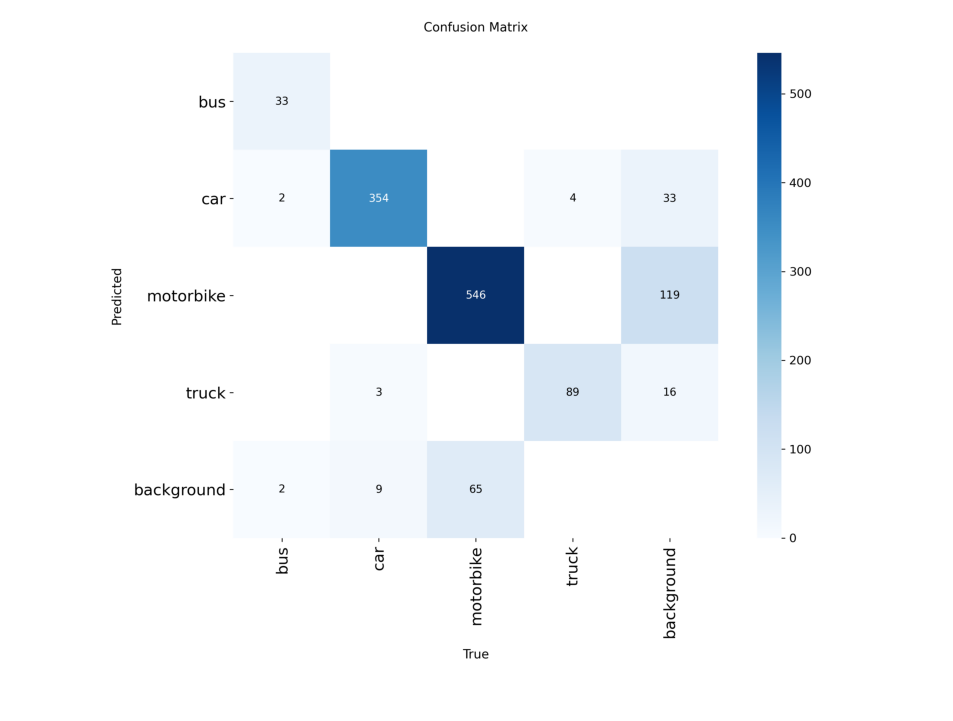

In [16]:
# Construct the path to the normalized confusion matrix image
confusion_matrix_path = os.path.join(run_dir, 'confusion_matrix.png')

# Read the image using cv2
cm_img = cv2.imread(confusion_matrix_path)

# Convert the image from BGR to RGB color space for accurate color representation with matplotlib
cm_img = cv2.cvtColor(cm_img, cv2.COLOR_BGR2RGB)

# Display the image
plt.figure(figsize=(10, 10), dpi=120)
plt.imshow(cm_img)
plt.axis('off')
plt.show()

In [17]:
# Define a function to plot learning curves for loss values
def plot_learning_curve(df, train_loss_col, val_loss_col, title):
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=df, x='epoch', y=train_loss_col, label='Train Loss', color='#141140', linestyle='-', linewidth=2)
    sns.lineplot(data=df, x='epoch', y=val_loss_col, label='Validation Loss', color='orangered', linestyle='--', linewidth=2)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

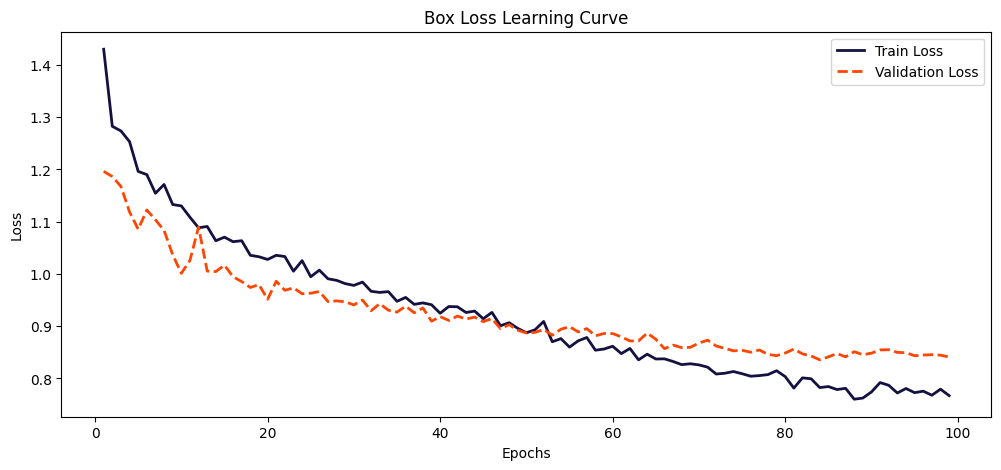

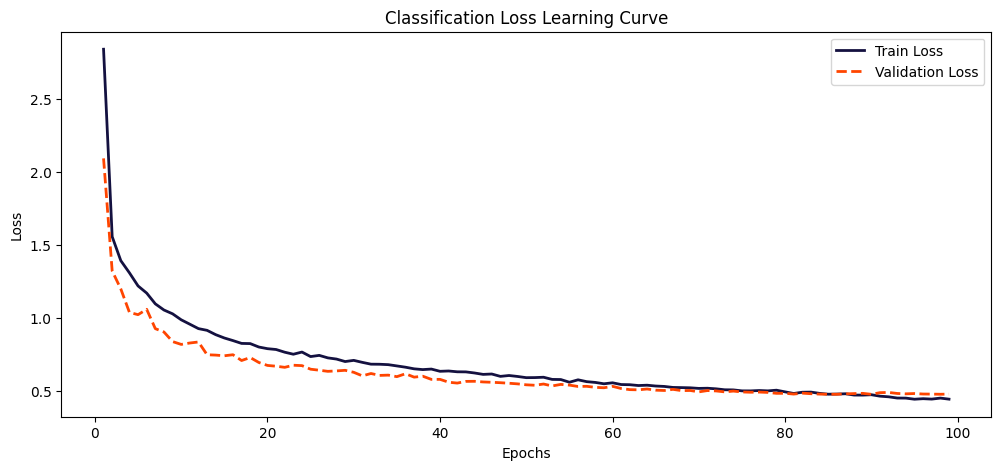

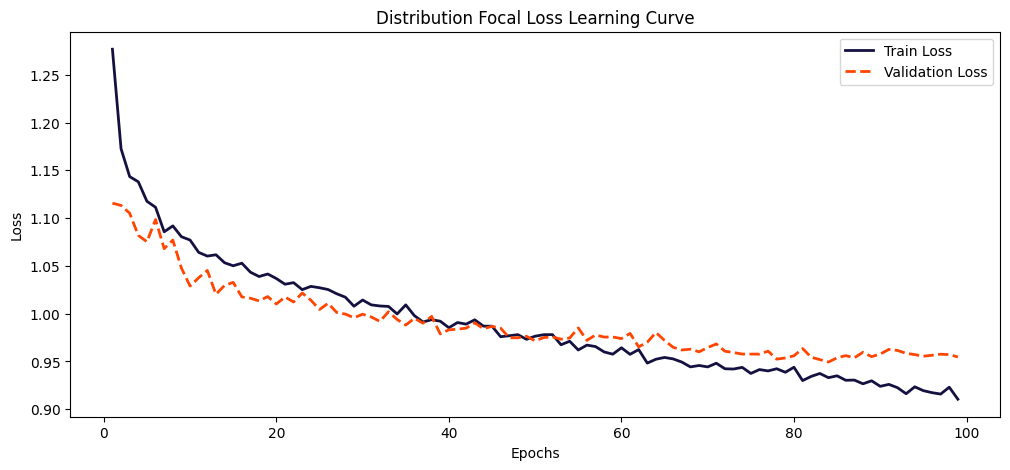

In [18]:
# Load the CSV file from the constructed path into a pandas DataFrame
df = pd.read_csv(results_csv_path)

# Remove any leading whitespace from the column names
df.columns = df.columns.str.strip()

# Plot the learning curves for each loss
plot_learning_curve(df, 'train/box_loss', 'val/box_loss', 'Box Loss Learning Curve')
plot_learning_curve(df, 'train/cls_loss', 'val/cls_loss', 'Classification Loss Learning Curve')
plot_learning_curve(df, 'train/dfl_loss', 'val/dfl_loss', 'Distribution Focal Loss Learning Curve')

In [19]:
# Final summary
print('Final summary')
print(f'Epochs trained: {EPOCHS}')
print(f'Best model path: {best_model_path}')
print(f'mAP50: {map50:.4f}')
print(f'mAP50-95: {map5095:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')

Final summary
Epochs trained: 100
Best model path: /content/drive/MyDrive/CS231/CS231_VehicleDetection/outputs/runs/detect/yolov8_raw_no_aug/weights/best.pt
mAP50: 0.9457
mAP50-95: 0.7668
Precision: 0.9295
Recall: 0.9013


In [20]:
all_results = []
for img_path in image_paths:
    # Run prediction and store the result object
    result = best_model.predict(source=str(img_path), conf=0.25, verbose=False, save=False)[0]

    # Calculate average confidence for all detected objects in this image
    avg_conf = 0.0
    if len(result.boxes) > 0:
        confidences = [float(box.conf[0].item()) for box in result.boxes]
        avg_conf = sum(confidences) / len(confidences)

    all_results.append({
        'img_path': img_path,
        'result_obj': result,
        'avg_conf': avg_conf
    })

# Sort results by average confidence in ascending order (lowest confidence first)
challenging_samples = sorted(all_results, key=lambda x: x['avg_conf'])[:4] # Get top 5 most challenging

if not challenging_samples:
    print('No challenging samples found with detections.')
else:
    cols = 2
    rows = (len(challenging_samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 6 * rows))
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1:
        axes = list(axes)
    else:
        axes = axes.flatten()

    print(f"Displaying {len(challenging_samples)} challenging prediction samples (lowest average confidence):")
    for ax, sample in zip(axes, challenging_samples):
        img_path = sample['img_path']
        result = sample['result_obj']
        avg_conf = sample['avg_conf']

        image = Image.open(img_path).convert('RGB')
        ax.imshow(image)
        ax.set_title(f"{img_path.name}\nAvg Conf: {avg_conf:.2f}")
        ax.axis('off')

        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            w, h = x2 - x1, y2 - y1
            cls_id = int(box.cls[0].item()) if box.cls is not None else -1
            conf = float(box.conf[0].item()) if box.conf is not None else 0.0
            cls_name = best_model.names.get(cls_id, str(cls_id))

            rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, max(y1 - 6, 0), f'{cls_name} {conf:.2f}', color='white', fontsize=9,
                    bbox=dict(facecolor='red', alpha=0.7, pad=1))

    # Turn off any unused subplots
    for ax in axes[len(challenging_samples):]:
        ax.axis('off')

    fig.suptitle('Challenging Test Predictions (Lowest Average Confidence)', fontsize=16)
    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.